# Work with real accelerometer data

In Module 3 you will record your own CSVs bookmark this section and repeat it then. 

For now, grab any 3-axis accelerometer CSV (ask the instructor for a sample with columns timestamp,accX,accY,accZ) and:

Load it: df = pd.read_csv("circle.1.csv")

Run df.describe() —

What are the min/max values? How do they correspond to the sensor's g-range (±4 g ≈ ±39.2 m/s²)?

What is the average value per axis? (Hint: at rest, gravity ≈ 9.81 m/s² shows on exactly one axis.)

In [ ]:
!pip install pandas matplotlib numpy

In [7]:
import pandas as pd
df = pd.read_csv('circle.2.csv')
df.describe()

,timestamp,accX,accY,accZ
count,943.000000,943.00000,943.000000,943.000000
mean,59037.219512,-271.71368,-14.624602,-316.934252
std,5214.535616,757.41391,868.551707,804.915890
min,51800.000000,-2000.00000,-2000.000000,-2000.000000
25%,54170.000000,-794.50000,-609.000000,-775.000000
50%,58880.000000,-273.00000,0.000000,-144.000000
75%,63590.000000,201.00000,619.000000,222.000000
max,68300.000000,1996.00000,1996.000000,1449.000000


Plot x, y, z as a line plot: df.plot()

Pick a threshold (e.g. ⅔ of the max amplitude), draw it with plt.axhline(...), and count how many samples exceed it ((df["accX"] > thr).sum())

<Axes: xlabel='timestamp'>

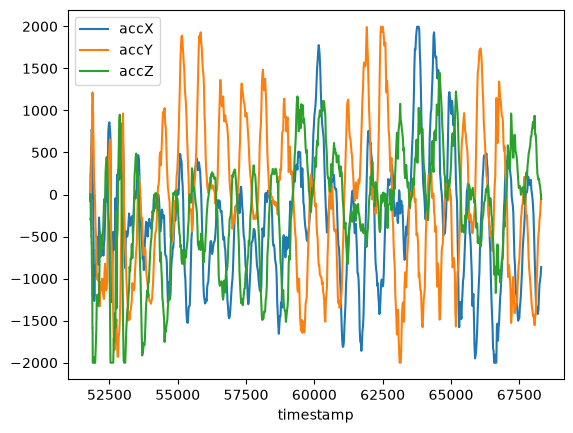

In [ ]:
#set index to timestamp column
df.set_index('timestamp', inplace=True)
df.plot()

Number of accX values above threshold: 84


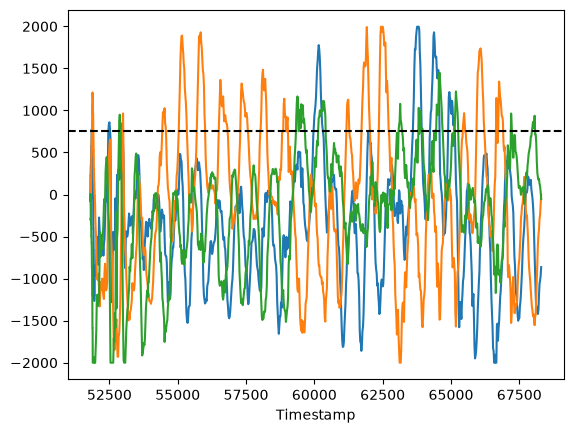

In [17]:
import matplotlib.pyplot as plt

thr = 750
plt.plot(df.index, df['accX'], label='accX')
plt.plot(df.index, df['accY'], label='accY')
plt.plot(df.index, df['accZ'], label='accZ')
plt.axhline(y=thr, color='k', linestyle='--', label='Treshold Line')
plt.xlabel('Timestamp')

#count X values above threshold
x_hi = ((df["accX"] > thr).sum())
print(f"Number of accX values above threshold: {x_hi}")


Plot a histogram (df.hist(bins=...)) —

How many bins do you need before the shape is visible?

Is the data Gaussian, or something else? Why might a gesture not be Gaussian?

Expected output (rest recording): describe() shows means near (0, 0, 9.8) and std well below 1 m/s²; the plot is three nearly flat lines.

array([[<Axes: title={'center': 'accX'}>,
        <Axes: title={'center': 'accY'}>],
       [<Axes: title={'center': 'accZ'}>, <Axes: >]], dtype=object)

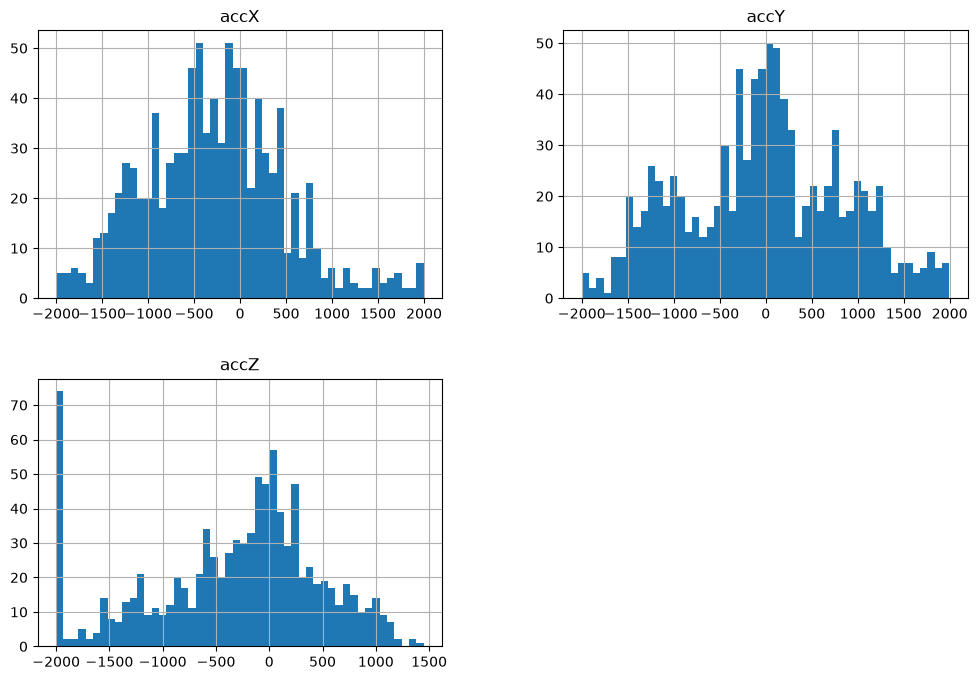

In [19]:
df.hist(bins=50, figsize=(12,8))